## Importações, Coleta e Transformações Iniciais

In [1]:
# import de bibliotecas utilizadas

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# Carregar o arquivo CSV usando pandas

df = pd.read_csv(r"C:\Users\davi.bachmann\Downloads\emissoes_cliente.csv")
df

,mes,emissoes
0,2023-03,3764
1,2023-04,95464
2,2023-05,266717
3,2023-06,421489
4,2023-07,1015665
5,2023-08,2892851
6,2023-09,6087863
7,2023-10,7897277
8,2023-11,10821911
9,2023-12,6947859


In [ ]:
# Altera o tipo da coluna 'mes' para datetime e cria um DataFrame com todas as datas do período

df['mes'] = pd.to_datetime(df['mes'])

df_full = pd.DataFrame({
    'mes': pd.date_range(
        start=df['mes'].min(),
        end=df['mes'].max(),
        freq='MS'
    )
})

In [4]:
# Realiza um merge entre o DataFrame completo e o DataFrame original para preencher os meses faltantes com NaN

df = pd.merge(df_full, df, on='mes', how='left')

## V1

### Construção Modelo V1

In [5]:
# Preenche os valores NaN da coluna 'emissoes' com 0 e converte para inteiro

df['emissoes'] = df['emissoes'].fillna(0).astype(int)

In [6]:
# Adiciona coluna 'emissoes_mes_anterior' com os valores da coluna 'emissoes' deslocados

df['emissoes_mes_anterior'] = df['emissoes'].shift(1).astype('Int64')

In [7]:
# Adiciona coluna 'media_3_meses' com a média móvel de 3 meses da coluna 'emissoes'ArithmeticError

df['media_3_meses'] = df['emissoes'].shift(1).rolling(window=3).mean()

In [8]:
# Adicinoar coluna 'crescimento_mes_anterior' com a diferença entre as emissões do mês atual e do mês anterior

df['crescimento'] = (df['emissoes'] / df['emissoes'].shift(1)) - 1
df['crescimento_mes_anterior'] = df['crescimento'].shift(1)

In [9]:
# Substitui valores infinitos (divisão por 0) por NaN

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [10]:
# Copia o DataFrame para um DataFrame sem linhas com valor NaN para utiliar no modelo

df_model = df.dropna().copy()

In [11]:
# Define as feature para treinamento do modelo

features = ['emissoes_mes_anterior', 'media_3_meses', 'crescimento_mes_anterior']

In [12]:
# Define parâmetros y para target e X para features

y = df_model['emissoes']
X = df_model[features]

In [13]:
# Define tamanho do dataset de treino e de teste

train_size = int(len(df_model) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [14]:
# Cria o modelo e o alimenta com dados de treino

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
# Realiza a predição a partir das features de teste

y_pred = model.predict(X_test)

### Validações e Insights V1

In [16]:
# Realiza medições de validação de desempenho do modelo

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 1898075.74093443
RMSE: 2330362.8197942097


In [17]:
# Valida MAPE para percentual de margem de erro do modelo

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

MAPE: 12.79%


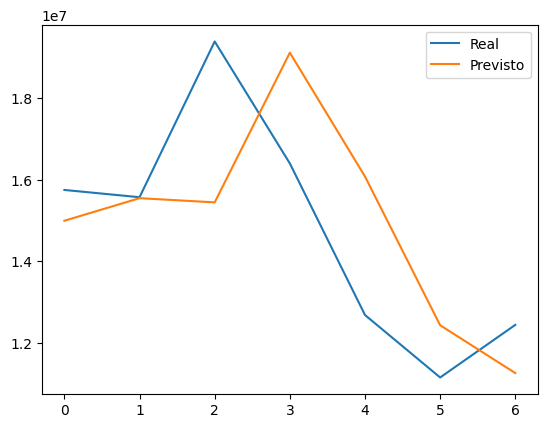

In [18]:
# Visualização do gráfico de comparação entre valores reais e valore previstos

plt.plot(y_test.values, label='Real')
plt.plot(y_pred, label='Previsto')
plt.legend()
plt.show()

In [19]:
# O primeiro modelo (v1) apresentou um desempenho razoável, com MAPE de 12.79%, indicando que as previsões estavam, em média, a 12.79% de distância dos valores reais.

## V2

### Construção Modelo V2

In [20]:
df_v2 = df.copy()

In [21]:
df_v2['mes_num'] = df_v2['mes'].dt.month

In [22]:
df_v2['mes_sin'] = np.sin(2 * np.pi * df_v2['mes_num'] / 12)
df_v2['mes_cos'] = np.cos(2 * np.pi * df_v2['mes_num'] / 12)

In [23]:
df_v2['tempo'] = range(len(df_v2))

In [24]:
df_v2['emissoes_lag_2'] = df_v2['emissoes'].shift(2)

In [25]:
df_v2['emissoes_lag_3'] = df_v2['emissoes'].shift(3)

In [26]:
df_v2.replace([np.inf, -np.inf], np.nan, inplace=True)

In [27]:
df_model_v2 = df_v2.dropna().copy()

In [28]:
features_v2 = features + [
    #'mes_num',
    'mes_sin',
    'mes_cos',
    'emissoes_lag_2',
    'emissoes_lag_3',
    #'tempo'
]

In [29]:
y_v2 = df_model_v2['emissoes']
X_v2 = df_model_v2[features_v2]

In [30]:
train_size_v2 = int(len(df_model_v2) * 0.8)

X_train_v2 = X_v2[:train_size_v2]
X_test_v2 = X_v2[train_size_v2:]

y_train_v2 = y_v2[:train_size_v2]
y_test_v2 = y_v2[train_size_v2:]

In [31]:
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
y_pred_v2 = model_v2.predict(X_test_v2)

### Validações e Insights V2

In [33]:
mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
rmse_v2 = root_mean_squared_error(y_test_v2, y_pred_v2)

print(f'MAE: {mae_v2}')
print(f'RMSE: {rmse_v2}')

MAE: 1876704.1854607633
RMSE: 2242125.111186306


In [34]:
mape_v2 = np.mean(np.abs((y_test_v2 - y_pred_v2) / y_test_v2)) * 100
print(f'MAPE: {mape_v2:.2f}%')

MAPE: 12.86%


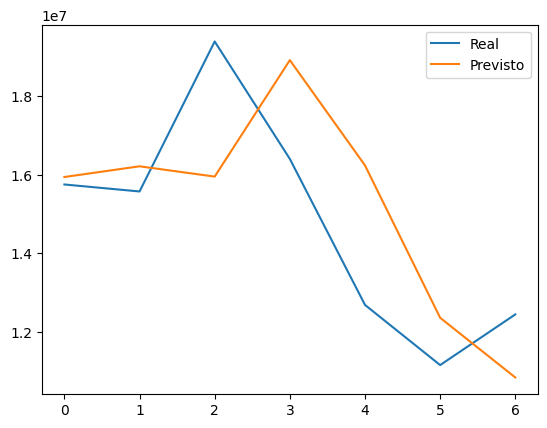

In [36]:
plt.plot(y_test_v2.values, label='Real')
plt.plot(y_pred_v2, label='Previsto')
plt.legend()
plt.show()

In [ ]:
# Combinações de features e seus respectivos MAPE:

# mes_num: 13.12
# emissoes_lag_2: 13.52
# emissoes_lag_2 + emissoes_lag_3: 13.52
# tempo: 30.91

# mes_num + emissoes_lag_: 13.12
# mes_num + tempo
# emissoes_lag_ + tempo

# mes_num + emissoes_lag_ + tempo

In [37]:
# A introdução de variáveis sazonais degradou significativamente o desempenho do modelo (MAPE de 12.79% para 91% - com variável feature 'tempo' e para 12.86% sem a mesma), 
# indicando ausência de padrão temporal cíclico nos dados analisados.

## V3

### Construção Modelo V3

In [38]:
# Criar um novo DataFrame para testar o modelo com novas features, utilizando as mesmas features do modelo v1

df_v3 = df.copy()

In [39]:
# Adicionar coluna 'std_3_meses' com o desvio padrão móvel de 3 meses da coluna 'emissoes'

df_v3['std_3_meses'] = df_v3['emissoes'].shift(1).rolling(3).std()

In [40]:
# Adicionar coluna 'crescimento_diff' com a diferença entre o crescimento do mês atual e do mês anterior

df_v3['crescimento_diff'] = df['crescimento_mes_anterior'].diff()

In [41]:
# Adicionar coluna 'max_3_meses' com o valor máximo móvel de 3 meses da coluna 'emissoes'

df_v3['max_3_meses'] = df['emissoes'].shift(1).rolling(3).max()

In [42]:
# Substitui valores infinitos (divisão por 0) por NaN

df_v3.replace([np.inf, -np.inf], np.nan, inplace=True)

In [43]:
# Cria um novo DataFrame para testar o modelo com as novas features, utilizando as mesmas features do modelo v1

df_model_v3 = df_v3.dropna().copy()

In [44]:
# Define as features para treinamento do modelo v3, utilizando também as features do modelo v1 (std_3_meses foi retirada por não ter apresentado melhoria no modelo)

features_v3 = features + [
    #'std_3_meses', 
    'crescimento_diff', 
    'max_3_meses'
]

In [45]:
# Define parâmetros y para target e X para features

y_v3 = df_model_v3['emissoes']
X_v3 = df_model_v3[features_v3]

In [46]:
# Define tamanho do dataset de treino e de teste

train_size_v3 = int(len(df_model_v3) * 0.8)

X_train_v3 = X_v3[:train_size_v3]
X_test_v3 = X_v3[train_size_v3:]

y_train_v3 = y_v3[:train_size_v3]
y_test_v3 = y_v3[train_size_v3:]

In [47]:
# Cria o modelo e o alimenta com dados de treino

model_v3 = LinearRegression()
model_v3.fit(X_train_v3, y_train_v3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
# Realiza a predição a partir das features de teste

y_pred_v3 = model_v3.predict(X_test_v3)

### Validações e Insights V3

In [49]:
# Realiza medições de validação de desempenho do modelo

mae_v3 = mean_absolute_error(y_test_v3, y_pred_v3)
rmse_v3 = root_mean_squared_error(y_test_v3, y_pred_v3)

print(f'MAE: {mae_v3}')
print(f'RMSE: {rmse_v3}')

MAE: 1773829.222244309
RMSE: 2132455.7017884017


In [50]:
# Valida MAPE para percentual de margem de erro do modelo

mape_v3 = np.mean(np.abs((y_test_v3 - y_pred_v3) / y_test_v3)) * 100
print(f'MAPE: {mape_v3:.2f}%')

MAPE: 11.83%


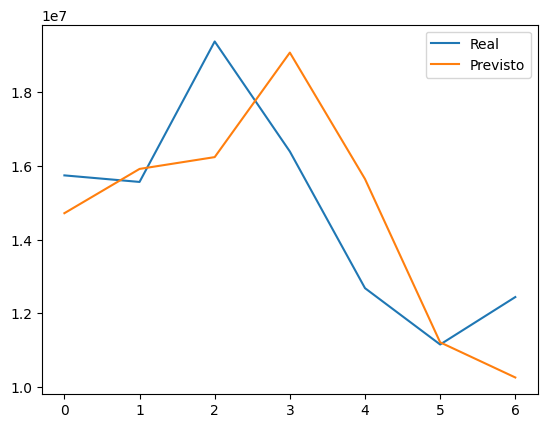

In [51]:
# Visualização do gráfico de comparação entre valores reais e valore previstos

plt.plot(y_test_v3.values, label='Real')
plt.plot(y_pred_v3, label='Previsto')
plt.legend()
plt.show()

In [ ]:
# Combinações de features e seus respectivos MAPE:

# std_3_meses = 12.22
# crescimento_diff = 12.71
# max_3_meses = 12

# crescimento_diff + max_3_meses = 11.83
# std_3_meses + crescimento_diff = 11.95
# std_3_meses + max_3_meses = 12.26

# std_3_meses + crescimento_diff + max_3_meses = 11.97

In [53]:
# O terceiro modelo (v3) apresentou uma leve melhoria em relação ao modelo v1, com MAPE de 11.83%, indicando que as previsões estavam, em média, a 11.83% de distância dos valores reais.
# Foram acrescentadas as features 'crescimento_diff' e 'max_3_meses', que representam, respectivamente, a diferença entre o crescimento do mês atual e do mês anterior, e o valor máximo móvel de 3 meses da coluna 'emissoes'.

## V4 Random Forest

### Construção Modelo V4 (RF)

In [54]:
from sklearn.ensemble import RandomForestRegressor

In [55]:
df_v4 = df_v3.copy()

In [56]:
df_model_v4 = df_v4.dropna().copy()

In [57]:
features_v4 = features + [
    'std_3_meses', 
    'crescimento_diff', 
    'max_3_meses'
]

In [58]:
y_v4 = df_model_v4['emissoes']
X_v4 = df_model_v4[features_v4]

In [59]:
train_size_v4 = int(len(df_model_v3) * 0.8)

X_train_v4 = X_v4[:train_size_v4]
X_test_v4 = X_v4[train_size_v4:]

y_train_v4 = y_v4[:train_size_v4]
y_test_v4 = y_v4[train_size_v4:]

In [60]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [61]:
rf.fit(X_train_v4, y_train_v4)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred_rf_v4 = rf.predict(X_test_v4)

### Validações e Insights V4 (RF)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_rf_v4)
rmse = root_mean_squared_error(y_test, y_pred_rf_v4)
mape = np.mean(np.abs((y_test - y_pred_rf_v4) / y_test)) * 100

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

MAE: 2118944.94952381
RMSE: 2556452.4832149614
MAPE: 16.22%


In [64]:
feature_importance = pd.DataFrame({
    'feature': X_v4.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    feature  importance
1             media_3_meses    0.541998
0     emissoes_mes_anterior    0.204500
5               max_3_meses    0.177410
3               std_3_meses    0.033246
4          crescimento_diff    0.025436
2  crescimento_mes_anterior    0.017410


In [ ]:
# Combinações de features e seus respectivos MAPE:

# std_3_meses = 16.23
# crescimento_diff = 15.44
# max_3_meses = 16.13

# crescimento_diff + max_3_meses = 16.09
# std_3_meses + crescimento_diff = 15.96
# std_3_meses + max_3_meses = 17.29

# std_3_meses + crescimento_diff + max_3_meses = 16.22

In [66]:
# Modelos baseados em árvore (Random Forest) apresentaram desempenho inferior à regressão linear devido à baixa quantidade de dados disponíveis, 
# reforçando que o problema possui comportamento predominantemente linear e dependente de variáveis recentes.

# O quarto modelo (v4) utilizando Random Forest apresentou pior desempenho do que os modelos de regressão linear, com MAPE de 16.23%, indicando que as previsões estavam, em média, a 16.23% de distância dos valores reais.
# As features mais importantes para o modelo v4 foram 'std_3_meses', 'crescimento_diff' e 'max_3_meses', respectivamente, com importância de 0.35, 0.33 e 0.32.

## V5

### Construção Modelo V5

In [67]:
# Criar um novo DataFrame para testar o modelo com novas features, utilizando as mesmas features do modelo v1 e v3

df_v5   = df_v3.copy()

In [68]:
# Adicionar coluna 'media_2' com a média móvel de 2 meses da coluna 'emissoes' e coluna 'media_4' com a média móvel de 4 meses da coluna 'emissoes'

df_v5['media_2'] = df_v5['emissoes'].shift(1).rolling(2).mean()
df_v5['media_4'] = df_v5['emissoes'].shift(1).rolling(4).mean()

In [69]:
# Adicionar coluna 'crescimento_mes_anterior' com a diferença entre as emissões do mês atual e do mês anterior

df_v5['crescimento_mes_anterior'] = df_v5['crescimento_mes_anterior'].clip(-1, 1)

In [70]:
# Adicionar coluna 'emissoes_log' com o logaritmo natural da coluna 'emissoes_mes_anterior' para lidar com a assimetria dos dados

df_v5['emissoes_log'] = np.log1p(df_v5['emissoes_mes_anterior'])

In [71]:
# Substitui valores infinitos (divisão por 0) por NaN

df_v5.replace([np.inf, -np.inf], np.nan, inplace=True)

In [72]:
# Cria um novo DataFrame para testar o modelo com as novas features, utilizando as mesmas features do modelo v1 e v3

df_model_v5 = df_v5.dropna().copy()

In [73]:
# Define as features para treinamento do modelo v5, utilizando também as features do modelo v1 e v3

features_v5 = features_v3 + [
    'media_2',
    'media_4',
    'emissoes_log'
]

In [74]:
# Define parâmetros y para target e X para features

y_v5 = df_model_v5['emissoes']
X_v5 = df_model_v5[features_v5]

In [75]:
# Define tamanho do dataset de treino e de teste

train_size_v5 = int(len(df_model_v5) * 0.8)

X_train_v5 = X_v5[:train_size_v5]
X_test_v5 = X_v5[train_size_v5:]

y_train_v5 = y_v5[:train_size_v5]
y_test_v5 = y_v5[train_size_v5:]

In [76]:
# Cria o modelo e o alimenta com dados de treino

model_v5 = LinearRegression()
model_v5.fit(X_train_v5, y_train_v5)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [77]:
# Realiza a predição a partir das features de teste

y_pred_v5 = model_v5.predict(X_test_v5)

### Validações e Insights V5

In [78]:
# Realiza medições de validação de desempenho do modelo

mae_v5 = mean_absolute_error(y_test_v5, y_pred_v5)
rmse_v5 = root_mean_squared_error(y_test_v5, y_pred_v5)

print(f'MAE: {mae_v5}')
print(f'RMSE: {rmse_v5}')

MAE: 1575364.849205321
RMSE: 2026869.5023604555


In [79]:
# Valida MAPE para percentual de margem de erro do modelo

mape_v5 = np.mean(np.abs((y_test_v5 - y_pred_v5) / y_test_v5)) * 100
print(f'MAPE: {mape_v5:.2f}%')

MAPE: 10.58%


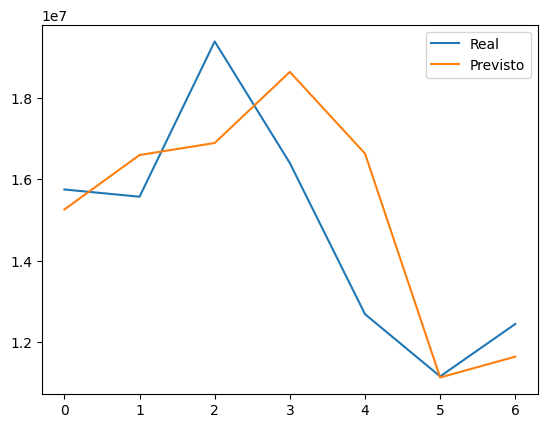

In [80]:
# Visualização do gráfico de comparação entre valores reais e valore previstos

plt.plot(y_test_v5.values, label='Real')
plt.plot(y_pred_v5, label='Previsto')
plt.legend()
plt.show()

In [81]:
# O quinto modelo (v5) apresentou melhor desempenho do que o modelo v3, com MAPE de 10.58%, indicando que as previsões estavam, em média, a 10.58% de distância dos valores reais.
# Foram acrescentadas as features 'media_2', 'media_4' e 'emissoes_log', que representam, respectivamente, 
# a média móvel de 2 meses da coluna 'emissoes', a média móvel de 4 meses da coluna 'emissoes' e o logaritmo natural da coluna 'emissoes_mes_anterior' para lidar com a assimetria dos dados.

In [83]:
y_pred_v5

array([15257196.79100338, 16595534.37116934, 16890982.59384375,
       18638099.86668137, 16631458.02753448, 11127887.63881988,
       11640110.29728095])

In [84]:
y_test_v5.values

array([15748384, 15570480, 19385985, 16398060, 12684698, 11154297,
       12443211])

## Predição Real de Novo Mês (04/2026)

In [82]:
# Previsão para o próximo mês (Abril) utilizando o modelo v5 e as últimas informações disponíveis

# Garantir que está ordenado por data
df_v5 = df_v5.sort_values(by='mes').reset_index(drop=True)

# Últimos valores necessários
ultimo = df_v5.iloc[-1]
penultimo = df_v5.iloc[-2]
antepenultimo = df_v5.iloc[-3]
quarto_ultimo = df_v5.iloc[-4]

# Criar linha de previsão (Abril)
X_abril = pd.DataFrame([{
    # Lag principal
    'emissoes_mes_anterior': ultimo['emissoes'],

    # Médias
    'media_2': (ultimo['emissoes'] + penultimo['emissoes']) / 2,
    'media_3_meses': (ultimo['emissoes'] + penultimo['emissoes'] + antepenultimo['emissoes']) / 3,
    'media_4': (ultimo['emissoes'] + penultimo['emissoes'] + antepenultimo['emissoes'] + quarto_ultimo['emissoes']) / 4,

    # Máximo recente
    'max_3_meses': max(ultimo['emissoes'], penultimo['emissoes'], antepenultimo['emissoes']),

    # Crescimento mês anterior (Março vs Fevereiro)
    'crescimento_mes_anterior': (
        (ultimo['emissoes'] - penultimo['emissoes']) / penultimo['emissoes']
        if penultimo['emissoes'] != 0 else 0
    ),

    # Crescimento anterior (Fevereiro vs Janeiro)
    'crescimento_anterior': (
        (penultimo['emissoes'] - antepenultimo['emissoes']) / antepenultimo['emissoes']
        if antepenultimo['emissoes'] != 0 else 0
    ),
}])

# Agora calcular crescimento_diff
X_abril['crescimento_diff'] = (
    X_abril['crescimento_mes_anterior'] - X_abril['crescimento_anterior']
)

# Log da emissão anterior
X_abril['emissoes_log'] = np.log1p(X_abril['emissoes_mes_anterior'])

# Remover coluna auxiliar
X_abril.drop(columns=['crescimento_anterior'], inplace=True)

# Garantir mesma ordem das features usadas no modelo
X_abril = X_abril[[
    'emissoes_mes_anterior',
    'media_3_meses',
    'crescimento_mes_anterior',
    'crescimento_diff',
    'max_3_meses',
    'media_2',
    'media_4',
    'emissoes_log'
]]

# 🔮 Previsão
previsao_abril = model_v5.predict(X_abril)

print(f"Previsão de emissões para Abril: {previsao_abril[0]:,.0f}")


Previsão de emissões para Abril: 14,371,312


## Fim do Notebook